In [111]:
# === IMPORTS ===
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [112]:
# ============================
# === CONFIGURATION ===
data_folder = "/kaggle/input/dataset4/archive_6.1"
tumor_types = ["
glioma", "meningioma", "notumor", "pituitary"]
IMG_SIZE = 150

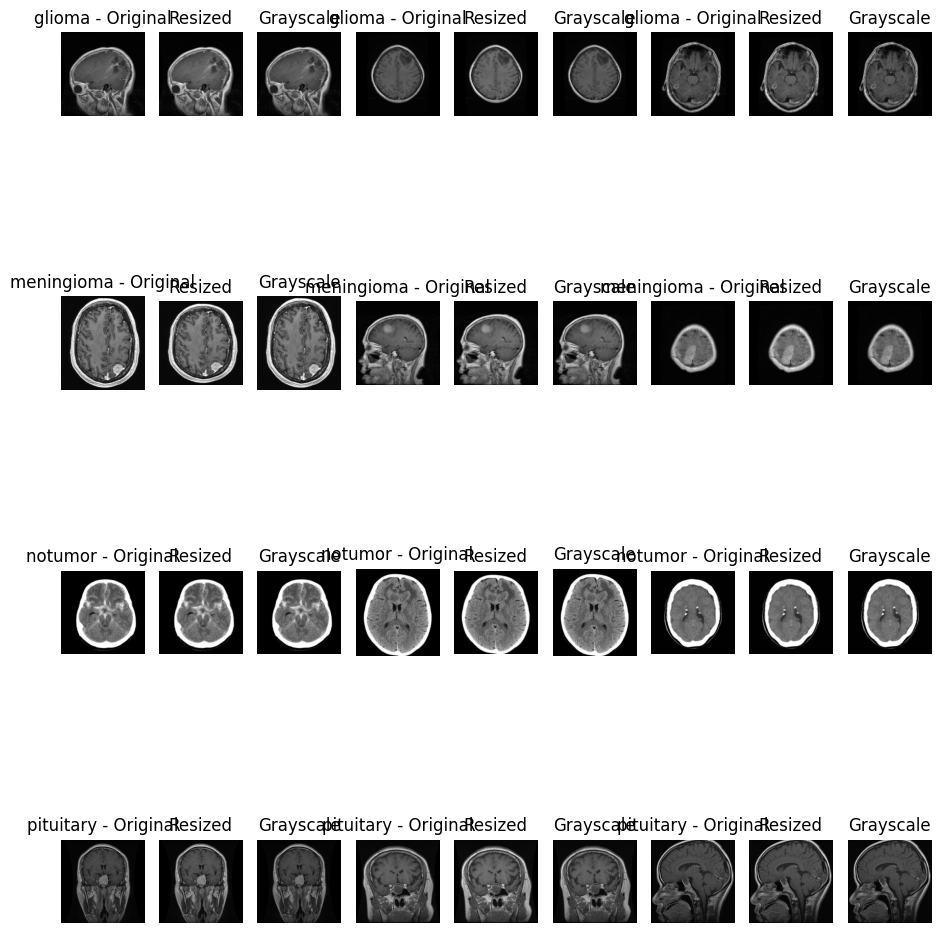

In [113]:
# 📌 VISUALIZATION FUNCTION
def visualize_sample_images(folder, tumor_types, IMG_SIZE, samples_per_class=3):
    classes = len(tumor_types)
    plt.figure(figsize=(samples_per_class * 3, classes * 3))

    for i, tumor_type_idx in enumerate(range(1, classes + 1)):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        images_displayed = 0
        for filename in os.listdir(tumor_folder):
            if images_displayed >= samples_per_class:
                break
            img_path = os.path.join(tumor_folder, filename)
            try:
                img_orig = Image.open(img_path).convert('L')
                img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE))
                img_gray = img_orig.convert('L')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 1)
                plt.imshow(img_orig, cmap='gray')
                plt.title(f"{tumor_types[i]} - Original")
                plt.axis('off')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 2)
                plt.imshow(img_resized, cmap='gray')
                plt.title("Resized")
                plt.axis('off')

                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 3)
                plt.imshow(img_gray, cmap='gray')
                plt.title("Grayscale")
                plt.axis('off')

                images_displayed += 1
            except:
                continue
    plt.tight_layout()
    plt.show()

visualize_sample_images(data_folder, tumor_types, IMG_SIZE)


In [114]:
# 📌 LOAD IMAGES (grayscale + resize + equalizeHist)
def load_images_from_folder(folder):
    images, labels = [], []
    for tumor_type_idx, tumor_type in enumerate(tumor_types, start=1):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        for filename in os.listdir(tumor_folder):
            img_path = os.path.join(tumor_folder, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img)
                img = cv2.equalizeHist(img)
                img = np.expand_dims(img, axis=-1)
                images.append(img)
                labels.append(tumor_type)
            except:
                continue
    return np.array(images), np.array(labels)

images, labels = load_images_from_folder(data_folder)
images = images.astype("float32") / 255.0


In [115]:
# ============================
# 📌 LABEL ENCODING
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_cat = to_categorical(labels_encoded)

In [116]:
# ============================
# 📌 TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_cat, test_size=0.2, stratify=labels_cat, random_state=42
)

In [117]:
# ============================
# 📌 IMAGE AUGMENTATION
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
train_gen = datagen.flow(X_train_new, y_train_new, batch_size=32)
val_gen = datagen.flow(X_val, y_val, batch_size=32)


In [118]:
# ============================
# 📌 MODEL DEFINITIONS CNN
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [119]:
# ============================
# 📌 MODEL DEFINITIONS ALEXNET
def build_alexnet(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(256, (5,5), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(256, (3,3), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [120]:
# ============================
# 📌 VGG16
def build_vgg16(input_shape, num_classes):
    base_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(3, (3,3), padding='same', input_shape=input_shape),
        base_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [121]:
# ============================
# 📌 IMPROVED GAN MODEL DEFINITIONS (Stabilized Version)
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(100,)),

        # Start small and progressively upscale
        tf.keras.layers.Dense(256 * 19 * 19, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Reshape((19, 19, 256)),

        # Upsample 1 → (38, 38)
        tf.keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),

        # Upsample 2 → (76, 76)
        tf.keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),

        # Upsample 3 → (152, 152)
        tf.keras.layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),

        # Crop to exact (150, 150)
        tf.keras.layers.Cropping2D(((1, 1), (1, 1))),

        # Final grayscale output
        tf.keras.layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh")
    ])
    return model



def build_discriminator(img_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=img_shape),

        # Convolutional blocks with spectral normalization style
        tf.keras.layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(256, kernel_size=4, strides=2, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(0.2),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(len(tumor_types), activation='softmax')
    ])

    # Slightly lower learning rate for discriminator
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model


In [122]:
# === IMPROVED GAN TRAINING FUNCTION ===
def train_gan(X_train, y_train, epochs=15, batch_size=64):
    generator = build_generator()
    discriminator = build_discriminator((IMG_SIZE, IMG_SIZE, 1))

    discriminator.trainable = False

    # Combined model
    z = tf.keras.Input(shape=(100,))
    img = generator(z)
    validity = discriminator(img)
    combined = tf.keras.Model(z, validity)

    optimizer_g = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    combined.compile(loss='categorical_crossentropy', optimizer=optimizer_g)

    half_batch = batch_size // 2

    for epoch in range(epochs):
        # Train Discriminator
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        imgs = X_train[idx]
        labels = y_train[idx]

        noise = np.random.normal(0, 1, (half_batch, 100))
        gen_imgs = generator.predict(noise)

        # Fake labels for generated images
        fake_labels = tf.keras.utils.to_categorical(
            np.random.randint(0, len(tumor_types), half_batch), num_classes=len(tumor_types)
        )

        # Train discriminator on real and fake
        d_loss_real = discriminator.train_on_batch(imgs, labels)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake_labels)

        # Train Generator (try to fool discriminator)
        noise = np.random.normal(0, 1, (batch_size, 100))
        valid_y = tf.keras.utils.to_categorical(np.ones(batch_size), num_classes=len(tumor_types))
        g_loss = combined.train_on_batch(noise, valid_y)

        print(f"Epoch {epoch + 1}/{epochs} | "
              f"D(real): {d_loss_real[0]:.4f}, D(fake): {d_loss_fake[0]:.4f}, G: {g_loss:.4f}")

    return discriminator

In [123]:
# ============================
# TRAIN BASE MODELS
input_shape = (IMG_SIZE, IMG_SIZE, 1)

print("Building and training CNN...")
cnn_model = build_cnn(input_shape, len(tumor_types))
cnn_model.fit(train_gen, validation_data=val_gen, epochs=15)

print("Building and training AlexNet...")
alexnet_model = build_alexnet(input_shape, len(tumor_types))
alexnet_model.fit(train_gen, validation_data=val_gen, epochs=15)

print("Building and training VGG16...")
vgg16_model = build_vgg16((IMG_SIZE, IMG_SIZE, 1), len(tumor_types))
vgg16_model.fit(train_gen, validation_data=val_gen, epochs=15)




Building and training CNN...
Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.3015 - loss: 1.7487 - val_accuracy: 0.4237 - val_loss: 1.2161
Epoch 2/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.4297 - loss: 1.2218 - val_accuracy: 0.5115 - val_loss: 1.1298
Epoch 3/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.4755 - loss: 1.1423 - val_accuracy: 0.5573 - val_loss: 1.0752
Epoch 4/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5315 - loss: 1.0320 - val_accuracy: 0.4466 - val_loss: 1.0825
Epoch 5/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5326 - loss: 1.0161 - val_accuracy: 0.5954 - val_loss: 1.0011
Epoch 6/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5742 - loss: 0.9750 - val_accuracy: 0.5420 - val_loss: 0.9589
Epoch 7/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5976 - loss: 0.9090 - val_accuracy: 0.6145 - val_loss: 0.9141
Epoch 8/15
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.6198 - loss: 0.8778 - val_accuracy: 0.5954 - val_loss: 0.

In [124]:
print("Training GAN discriminator as classifier...")
gan_discriminator = train_gan(X_train, y_train, epochs=15, batch_size=64)

Training GAN discriminator as classifier...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/15 | D(real): 1.3649, D(fake): 1.3756, G: 1.3754
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Epoch 2/15 | D(real): 1.3778, D(fake): 1.3799, G: 1.3380
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 3/15 | D(real): 1.3813, D(fake): 1.3821, G: 1.3088
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 4/15 | D(real): 1.3805, D(fake): 1.3812, G: 1.2867
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 5/15 | D(real): 1.3816, D(fake): 1.3821, G: 1.2684
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Epoch 6/15 | D(real): 1.3816, D(fake): 1.3820, G: 1.2524
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 7/15 | D(real): 1.3814, D(fake): 1.3817, G: 1.2394
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Epoch 8/15 | D(real): 1.3819, D(fake): 1.3822, G: 1.2257
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Epoch 9/15 | D(real): 1.3826, D(fake): 1.3828, G: 1.2148
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 10/15 | D(real): 1.3832, D(fake): 1.3833, G: 1.2038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Epoch 11/15 | D(real): 1.3842, D(fake): 1.3843, G

In [125]:
# ============================
# PREDICTIONS FOR ENSEMBLE
pred_cnn = cnn_model.predict(X_test)
pred_alex = alexnet_model.predict(X_test)
pred_vgg = vgg16_model.predict(X_test)
pred_gan = gan_discriminator.predict(X_test)
y_true = np.argmax(y_test, axis=1)
vgg16_model.save("vgg16_model.h5")
print("✅ VGG16 model saved as vgg16_model.h5")
print("\nIndividual Model Accuracies:")
print("CNN:", accuracy_score(y_true, np.argmax(pred_cnn, axis=1)))
print("AlexNet:", accuracy_score(y_true, np.argmax(pred_alex, axis=1)))
print("VGG16:", accuracy_score(y_true, np.argmax(pred_vgg, axis=1)))
print("GAN:", accuracy_score(y_true, np.argmax(pred_gan, axis=1)))


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
✅ VGG16 model saved as vgg16_model.h5

Individual Model Accuracies:
CNN: 0.6768759571209801
AlexNet: 0.2879019908116386
VGG16: 0.8667687595712098
GAN: 0.2879019908116386


In [126]:
#Only Ensemble
avg_pred = (pred_cnn + pred_alex + pred_vgg+pred_gan) / 4
avg_acc = accuracy_score(y_true, np.argmax(avg_pred, axis=1))
print("\nAverage Ensemble Accuracy:", avg_acc)


Average Ensemble Accuracy: 0.8453292496171516


In [127]:
# Grid Search for optimal weight

In [128]:
# Grid Search-based weighted ensemble

In [129]:
# GRID SEARCH FOR ENSEMBLE
preds = np.array([pred_cnn, pred_alex, pred_vgg, pred_gan])
results = []
for w1 in range(0, 11):
    for w2 in range(0, 11):
        for w3 in range(0, 11):
            for w4 in range(0, 11):
                total = w1 + w2 + w3 + w4
                if total == 0: continue
                weights = [w1/total, w2/total, w3/total, w4/total]
                weighted_preds = np.tensordot(preds, weights, axes=((0), (0)))
                y_pred = np.argmax(weighted_preds, axis=1)
                acc = accuracy_score(y_true, y_pred) * 100
                results.append({
                    'w_cnn': weights[0], 'w_alex': weights[1],
                    'w_vgg': weights[2], 'w_gan': weights[3],
                    'accuracy': acc
                })

df = pd.DataFrame(results)
best = df.loc[df['accuracy'].idxmax()]
print(f"\n✅ Best Weighted Accuracy: {best['accuracy']:.2f}%")
print(f"Optimal Weights -> CNN: {best['w_cnn']:.2f}, AlexNet: {best['w_alex']:.2f}, VGG16: {best['w_vgg']:.2f}, GAN: {best['w_gan']:.2f}")



✅ Best Weighted Accuracy: 86.83%
Optimal Weights -> CNN: 0.09, AlexNet: 0.00, VGG16: 0.18, GAN: 0.73


In [130]:
# === ii) Weighted Average Ensemble ===
# Example weights - You can modify based on model accuracy
w_cnn = 0.41
w_alex = 0.06
w_vgg = 0.4
w_gan = 0.1


weighted_pred = (w_cnn * pred_cnn) + (w_alex * pred_alex) + (w_vgg * pred_vgg)+(w_vgg * pred_gan)
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# Accuracy
weighted_accuracy = accuracy_score(y_true, weighted_pred_labels)
print(f"\n📌 Weighted Average Ensemble Accuracy: {weighted_accuracy:.4f}")


📌 Weighted Average Ensemble Accuracy: 0.8484



Final Weighted Ensemble Accuracy: 0.8683001531393568

Classification Report:
              precision    recall  f1-score   support

      glioma       0.91      0.83      0.87       185
  meningioma       0.82      0.78      0.80       188
     notumor       0.94      0.91      0.92       100
   pituitary       0.85      0.98      0.91       180

    accuracy                           0.87       653
   macro avg       0.88      0.87      0.87       653
weighted avg       0.87      0.87      0.87       653



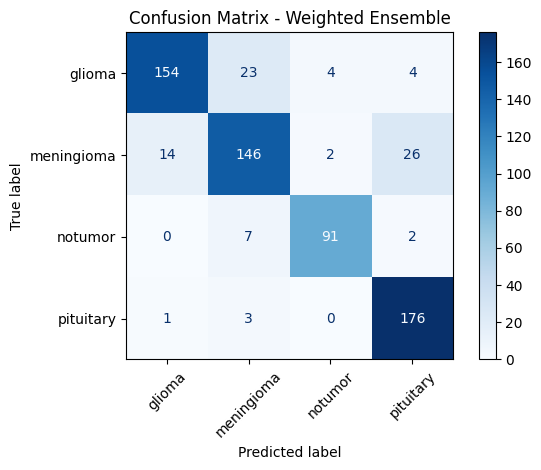

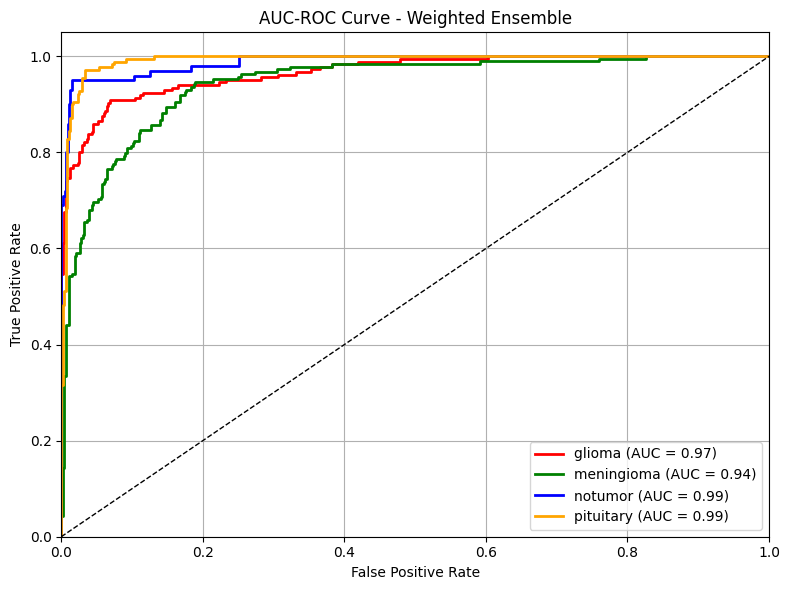

In [131]:
# ============================
# FINAL EVALUATION WITH BEST WEIGHTS
# ============================
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Apply best weights from grid search
w_cnn = best['w_cnn']
w_alex = best['w_alex']
w_vgg = best['w_vgg']
w_gan = best['w_gan']

# Weighted ensemble prediction
weighted_pred = (w_cnn * pred_cnn) + (w_alex * pred_alex) + (w_vgg * pred_vgg) + (w_gan * pred_gan)
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# Final accuracy and classification report
print("\nFinal Weighted Ensemble Accuracy:", accuracy_score(y_true, weighted_pred_labels))
print("\nClassification Report:")
print(classification_report(y_true, weighted_pred_labels, target_names=le.classes_))

# ============================
# 📊 CONFUSION MATRIX
# ============================
cm = confusion_matrix(y_true, weighted_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Weighted Ensemble")
plt.tight_layout()
plt.show()

# ============================
# 📈 ROC-AUC CURVE PER CLASS
# ============================
y_true_bin = label_binarize(y_true, classes=range(len(tumor_types)))
n_classes = y_true_bin.shape[1]
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], weighted_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'orange']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - Weighted Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


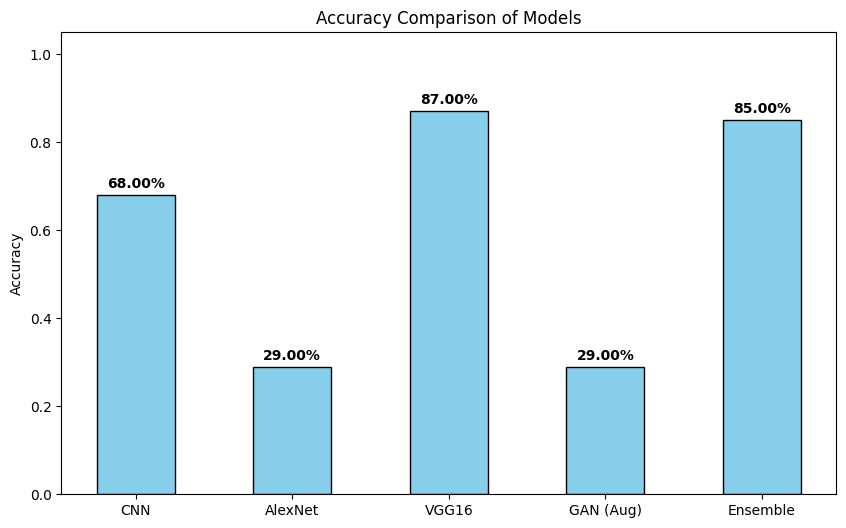

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Actual accuracies
models = ["CNN", "AlexNet", "VGG16", "GAN (Aug)", "Ensemble"]
accuracy = [0.68, 0.29, 0.87, 0.29, 0.85]

x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(x, accuracy, width, color="skyblue", edgecolor="black")

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison of Models')
ax.set_xticks(x)
ax.set_xticklabels(models)

# Add accuracy values above each bar (percentage format)
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    ax.annotate(f'{acc*100:.2f}%',   # convert to %
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.ylim(0, 1.05)  # scale up to 100% = 1.0
plt.show()


In [135]:
# ============================
# 📉 LOSS FUNCTION EVALUATION (for Optimal Weights)
# ============================
from sklearn.metrics import (
    log_loss, mean_absolute_error,
    mean_squared_error, cohen_kappa_score, hamming_loss
)

# Use the weighted predictions you already computed during grid search
# (Make sure 'weighted_preds' and 'y_pred' or 'weighted_pred_labels' are already available)

# === Compute Loss Metrics ===
logloss = log_loss(y_true, weighted_preds)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
h_loss = hamming_loss(y_true, y_pred)

# === Display Results ===
print("\n==============================")
print("📉 LOSS FUNCTION METRICS (Optimal Weights)")
print("==============================")
print(f"🔻 Log Loss (Cross-Entropy): {logloss:.4f}")
print(f"🔸 Mean Absolute Error: {mae:.4f}")
print(f"🔹 Mean Squared Error: {mse:.4f}")
print(f"📘 Cohen's Kappa Score: {kappa:.4f}")
print(f"📕 Hamming Loss: {h_loss:.4f}")



📉 LOSS FUNCTION METRICS (Optimal Weights)
🔻 Log Loss (Cross-Entropy): 0.7756
🔸 Mean Absolute Error: 0.2343
🔹 Mean Squared Error: 0.4181
📘 Cohen's Kappa Score: 0.7900
📕 Hamming Loss: 0.1547
